# Lab 4.05 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 5 - Survey of Australian Students

Load the data file data/survey.csv. It contains the result of a survey of students from an Australian university.

We want to investigate the relationship between some discrete (nominal or ordinal) variables in this dataset. For any pairs of variables listed below, follow these steps:

* First, think about what exactly you expect for the given combination of variables.
* Make a frequency table for the two variables. The (presumably) independent variable comes first.
* Plot a graph visualizing the relationship between the two variables.
- Looking at the chart, do you expect a rather high or rather low value for the $\chi^2$ statistic? Why?
* Run the $\chi^2$ test to determine whether there is a relationship between the two variables. Calculate the $\chi^2$ statistic, the critical limit $g$ and the $p$ value, each for significance level $\alpha = 0.05$.
* Should we accept or reject the null hypothesis? What exactly does that mean for the relationship between the two variables? In other words, formulate an answer to the research question.
* Calculate Cramér's V. Do you come to a similar conclusion as with the $\chi^2$ test?


The variables to be investigated:

| Independent variabele          | Dependent variabele                        |
|:------------------------------ |:-------------------------------------------|
| `Exer` (practicing sports)     | `Smoke`                                    |
| `Sex` (gender)                 | `Smoke`                                    |
| `W.Hnd` (dominant hand)        | `Fold` (top hand when you cross your arms) |
| `Sex`                          | `W.Hnd`                                    |

Results of the main calculations (rounded up to 3 decimal places):

- `Exer/Smoke`: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483
- `W.Hnd/Fold`: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454
- `Sex/Smoke`: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314
- `Sex/W.Hnd`: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627

Read the dataset. **Be careful!** The `read_csv()` function does not handle missing values in this dataset correctly. Missing values are represented by the string "NA", which is automatically detected by `read_csv()` as a missing value. However, it will also convert the value 'None' in the column 'Exer' to a missing value, which is not correct. To prevent this, set the parameters `na_values` to the *only* valid missing value "NA" and `keep_default_na` to `False` when calling `read_csv()`. This way, the value 'None' will be read as a valid value in the 'Exer' column.

In [41]:
survey = pd.read_csv("../data/survey.csv",index_col=0,keep_default_na=False,na_values=['NA'])

survey['Sex'] = survey['Sex'].astype('category')
survey['W.Hnd'] = survey['W.Hnd'].astype('category')
survey['Fold'] = survey['Fold'].astype('category')
survey['Clap'] = survey['Clap'].astype('category')
survey['M.I'] = survey['M.I'].astype('category')

survey['Exer'] = survey['Exer'].astype(
    CategoricalDtype(categories=['None', 'Some', 'Freq'], ordered=True)
)
survey['Smoke'] = survey['Smoke'].astype(
    CategoricalDtype(categories=['Never', 'Occas', 'Regul', 'Heavy'], ordered=True)
)

survey.head()

,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
1,Female,18.5,18.0,Right,R on L,92.0,Left,Some,Never,173.0,Metric,18.250
2,Male,19.5,20.5,Left,R on L,104.0,Left,None,Regul,177.8,Imperial,17.583
3,Male,18.0,13.3,Right,L on R,87.0,Neither,None,Occas,NaN,NaN,16.917
4,Male,18.8,18.9,Right,R on L,NaN,Neither,None,Never,160.0,Metric,20.333
5,Male,20.0,20.0,Right,Neither,35.0,Right,Some,Never,165.0,Metric,23.667


In [35]:
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 237 entries, 1 to 237
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Sex     236 non-null    category
 1   Wr.Hnd  236 non-null    float64 
 2   NW.Hnd  236 non-null    float64 
 3   W.Hnd   236 non-null    category
 4   Fold    237 non-null    category
 5   Pulse   192 non-null    float64 
 6   Clap    236 non-null    category
 7   Exer    237 non-null    category
 8   Smoke   236 non-null    category
 9   Height  209 non-null    float64 
 10  M.I     209 non-null    category
 11  Age     237 non-null    float64 
dtypes: category(7), float64(5)
memory usage: 11.4 KB


What are the different values for Exer and Smoke?  
Change both variables to ordinal variables with a specific order.

In [36]:
exer_smoke = pd.crosstab(survey.Smoke,survey.Exer)
exer_smoke

Exer,None,Some,Freq
Smoke,,,
Never,18,84,87
Occas,3,4,12
Regul,1,7,9
Heavy,1,3,7


In [48]:
chi2, p_value, dof, expected = stats.chi2_contingency(exer_smoke)

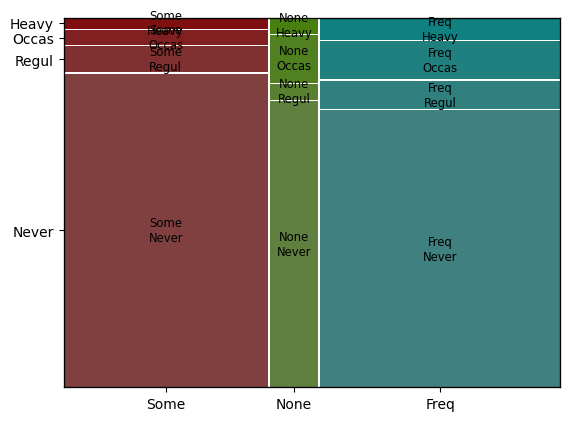

In [47]:
mosaic(data=survey, index=['Exer', 'Smoke']);

* Make a frequency table for the two variables. The (presumably) independent variable comes first.
* Plot a graph visualizing the relationship between the two variables.
* Looking at the chart, do you expect a rather high or rather low value for the  χ2  statistic? Why?
* Run the  χ2  test to determine whether there is a relationship between the two variables. Calculate the  χ2  statistic, the critical limit  g  and the  p  value, each for significance level  α=0.05 .
* Should we accept or reject the null hypothesis? What exactly does that mean for the relationship between the two variables? In other words, formulate an answer to the research question.
* Calculate Cramér's V. Do you come to a similar conclusion as with the  χ2  test?

The variables to be investigated:

| Independent variabele          | Dependent variabele                        |
|:------------------------------ |:-------------------------------------------|
| `Exer` (practicing sports)     | `Smoke`                                    |
| `Sex` (gender)                 | `Smoke`                                    |
| `W.Hnd` (dominant hand)        | `Fold` (top hand when you cross your arms) |
| `Sex`                          | `W.Hnd`                                    |

Results of the main calculations (rounded up to 3 decimal places):

- `Exer/Smoke`: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483
- `W.Hnd/Fold`: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454
- `Sex/Smoke`: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314
- `Sex/W.Hnd`: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627

Exer/Smoke: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483

Critical value: 12.59
Chi-squared value: 5.49


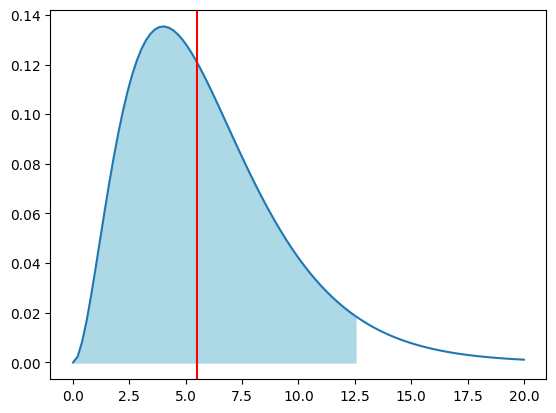

In [51]:
# Plot of the case:
# x-values:
x = np.linspace(0, 20, num=100)
# probability density of the chi-squared distribution with 4 degrees of freedom
y = stats.chi2.pdf(x, df=6)
# the critical value g for which the right tail probability is exactly 5%:
g = stats.chi2.isf(.05, df=6)

plt.plot(x, y)                     # probability density
plt.fill_between(x, y, where=x<=g, # critical area
    color='lightblue')
plt.axvline(chi2, color='red');    # chi-squared

print(f'Critical value: {g:.2f}')
print(f'Chi-squared value: {chi2:.2f}')

In [49]:
# cramers V
np.sqrt(chi2 / (exer_smoke.sum().sum() * (min(exer_smoke.shape) - 1)))

np.float64(0.10783448053343489)

W.Hnd/Fold: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454

Sex/Smoke: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314

Sex/W.Hnd: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627